## Email Spam Detection Project 

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

In [2]:
eml = pd.read_csv('spam.csv')
eml.head()

,Category,Message
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


In [3]:
eml.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5572 entries, 0 to 5571
Data columns (total 2 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   Category  5572 non-null   object
 1   Message   5572 non-null   object
dtypes: object(2)
memory usage: 87.2+ KB


In [4]:
eml.duplicated().sum()

np.int64(415)

In [5]:
eml.drop_duplicates(inplace=True) # remove duplicate values

In [6]:
eml.info()

<class 'pandas.core.frame.DataFrame'>
Index: 5157 entries, 0 to 5571
Data columns (total 2 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   Category  5157 non-null   object
 1   Message   5157 non-null   object
dtypes: object(2)
memory usage: 120.9+ KB


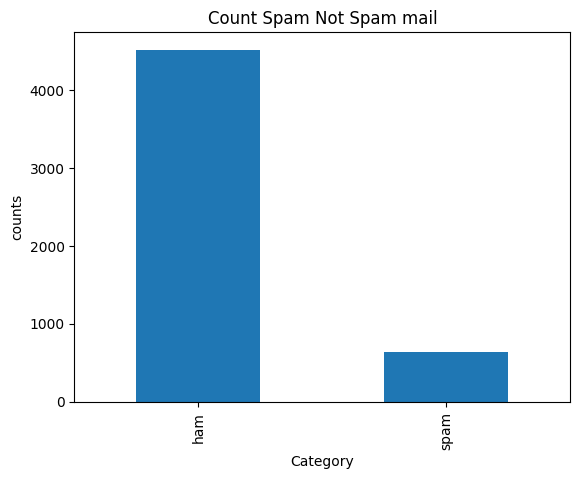

In [7]:
# creat barplot visualize clearly see it is inbalance dataset
eml['Category'].value_counts().plot(kind='bar')
plt.title('Count Spam Not Spam mail')
plt.ylabel('counts')
plt.show()

In [8]:
eml[eml['Category'] == 'spam']
ham_msg = eml[eml['Category'] == 'ham']

In [9]:
ham_msg

,Category,Message
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."
6,ham,Even my brother is not like to speak with me. ...
...,...,...
5565,ham,Huh y lei...
5568,ham,Will ü b going to esplanade fr home?
5569,ham,"Pity, * was in mood for that. So...any other s..."
5570,ham,The guy did some bitching but I acted like i'd...


In [7]:
import string
import nltk
from nltk.corpus import stopwords
from wordcloud import WordCloud
from nltk.tokenize import word_tokenize

In [11]:
def remove_punc(text):
    remove = str.maketrans("","", string.punctuation)
    return text.translate(remove)

eml['Message'] = eml['Message'].apply(lambda x: remove_punc(x))

In [12]:
eml.head()

,Category,Message
0,ham,Go until jurong point crazy Available only in ...
1,ham,Ok lar Joking wif u oni
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor U c already then say
4,ham,Nah I dont think he goes to usf he lives aroun...


In [13]:
# Remove stop words

def remove_stop_word(text):
    stop_word = set(stopwords.words('English'))
    word = word_tokenize(text)
    clean_text = []
    for t in word:
        if not t in stop_word:
            clean_text.append(t)
    return " ".join(clean_text)
    
eml['Message'] = eml['Message'].apply(lambda x: remove_stop_word(x))
eml['Message'] = eml['Message'].apply(lambda x: x.lower())

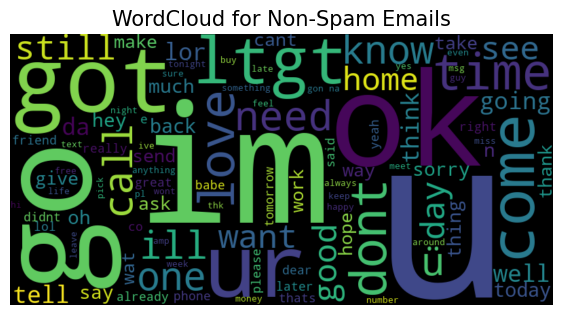

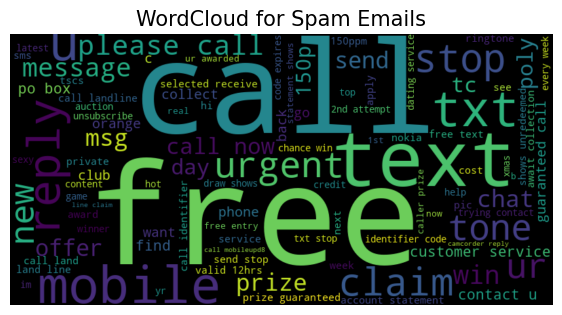

In [14]:
def plot_word_cloud(data, typ):
    email_sen = " ".join(data['Message']) 
    wc = WordCloud(background_color='black',  height=400, max_words=100, width=800).generate(email_sen)
    plt.figure(figsize=(7, 7))
    plt.imshow(wc, interpolation='bilinear')
    plt.title(f'WordCloud for {typ} Emails', fontsize=15)
    plt.axis('off')
    plt.show()

plot_word_cloud(eml[eml['Category'] == 'ham'], typ='Non-Spam')
plot_word_cloud(eml[eml['Category'] == 'spam'], typ='Spam')

In [15]:
eml['Category'] = eml['Category'].map({'ham': 0, 'spam':1})

In [16]:
eml.head(3)

,Category,Message
0,0,go jurong point crazy available bugis n great ...
1,0,ok lar joking wif u oni
2,1,free entry 2 wkly comp win fa cup final tkts 2...


In [17]:
from sklearn.feature_extraction.text import TfidfVectorizer

In [18]:
# Convert Text into Vector using tfidfvector

vectorizer = TfidfVectorizer(max_features=5000, ngram_range=(1,2))
x = vectorizer.fit_transform(eml['Message'])

In [19]:
y = eml['Category']

In [20]:
from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(x,y, test_size=0.2, random_state=42, stratify=y)

In [21]:
# model Using LogisticRegression

from sklearn.linear_model import LogisticRegression
lr = LogisticRegression(class_weight='balanced')
model = lr.fit(x_train,y_train)

In [22]:
from sklearn.metrics import confusion_matrix, accuracy_score

In [23]:
y_pred = model.predict(x_test)

In [24]:
cm = confusion_matrix(y_test, y_pred)

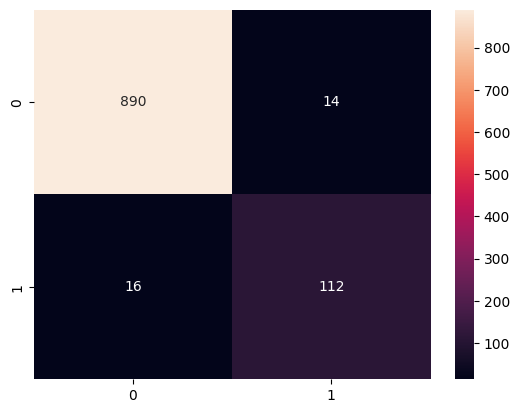

In [25]:
sns.heatmap(data=cm, annot=True, fmt='d')
plt.show()

In [26]:
train = model.predict(x_train)

In [27]:
# Training Accuracy
train_acc = accuracy_score(y_train, train)
train_acc

0.9903030303030304

In [28]:
# Testing Accuracy
test_acc = accuracy_score(y_test, y_pred)

In [29]:
test_acc

0.9709302325581395

In [30]:
from sklearn.metrics import confusion_matrix, classification_report

cr = classification_report(y_test, y_pred)
print(cr)

              precision    recall  f1-score   support

           0       0.98      0.98      0.98       904
           1       0.89      0.88      0.88       128

    accuracy                           0.97      1032
   macro avg       0.94      0.93      0.93      1032
weighted avg       0.97      0.97      0.97      1032



In [60]:
import joblib

In [64]:
# Save model
final_model = joblib.dump(model, 'Email_Spam_Prediction.pkl')

In [1]:
from joblib import dump, load

In [ ]:

dump(vectorizer, "tfidf_vectorizer.pkl")

['tfidf_vectorizer.pkl']

In [71]:
# Load the model to predict msg
model = load("Email_Spam_Prediction.pkl")
vectorizer = load("tfidf_vectorizer.pkl")

In [79]:
email = "Hi All,I finally fixed the RPM build bug for the webserver deployment. I had to manually change the file installation directory flags inside the spec script. I am going to route any non-LAN traffic through ppp0 for testing now. Let me know if you hit any compilation errors on your local environments."
email_vector = vectorizer.transform([email])

prediction = model.predict(email_vector)
print(prediction)

[0]


In [31]:
y_test.shape

(1032,)

# Testing for another model 

In [32]:
from sklearn.naive_bayes import MultinomialNB, BernoulliNB

In [33]:
mb = MultinomialNB()
model_2 = mb.fit(x_train, y_train)
y_pred_1 = model_2.predict(x_test)

In [34]:
cr = confusion_matrix(y_test, y_pred_1)
cr

array([[904,   0],
       [ 30,  98]])

In [51]:
bl = BernoulliNB()
model_3 = bl.fit(x_train, y_train)
y_pred_2 = model_3.predict(x_test)

In [52]:
cf = confusion_matrix(y_test, y_pred_2)

In [53]:
cf

array([[903,   1],
       [ 26, 102]])

In [54]:
cr = classification_report(y_test, y_pred_2)

In [55]:
print(cr)

              precision    recall  f1-score   support

           0       0.97      1.00      0.99       904
           1       0.99      0.80      0.88       128

    accuracy                           0.97      1032
   macro avg       0.98      0.90      0.93      1032
weighted avg       0.97      0.97      0.97      1032



In [4]:
from xgboost import XGBClassifier

In [57]:
xgb = XGBClassifier(class_weight='balance')
model_4 = xgb.fit(x_train, y_train)
y_pred_4 = model_4.predict(x_test)

In [58]:
cf = confusion_matrix(y_test, y_pred_4)

In [59]:
cf

array([[897,   7],
       [ 32,  96]])